# He Yellow (587 nm) Zeeman Effect

This notebook is optimized for **quick preprocessing** of paired images:

- `vdc0_He_yellow_587_sigma.png`, `vdc0_He_yellow_587_pi.png`
- `vdc5_He_yellow_587_sigma.png`, `vdc5_He_yellow_587_pi.png`
- ... up to VDC 30

It caches the expensive radial profiles in `cache_dir` so we only preprocess once.


In [2]:
from pathlib import Path
import numpy as np

# Point this to the folder containing your PNGs.
# If the images are in ATM/zeeman, keep it as '.'
data_dir = Path('.').resolve()

# Cache folder (radial profiles get saved here)
cache_dir = (data_dir / 'yellow_cache').resolve()
cache_dir.mkdir(parents=True, exist_ok=True)

# VDC -> B mapping (kG)
VDC_VALUES = [0, 5, 10, 15, 20, 25, 30]
B_FIELDS_KG = np.array([0.2, 1.5, 2.97, 4.02, 5.97, 7.35, 9.3], dtype=float)

# Etalon thickness
etalon_thickness_cm = 0.811

# Fast preprocessing settings
nbins = 2000
center_step = 2   # 2–3x faster center search; set to 1 for maximum precision

# Build the expected filename list: [sigma0, pi0, sigma5, pi5, ...]
image_paths = []
for vdc in VDC_VALUES:
    base = f'vdc{vdc}_He_yellow_587'
    sigma_p = data_dir / f'{base}_sigma.png'
    pi_p = data_dir / f'{base}_pi.png'
    image_paths.extend([sigma_p, pi_p])

# Validate
missing = [p for p in image_paths if not p.exists()]
if missing:
    raise FileNotFoundError('Missing files:\n' + '\n'.join(str(p) for p in missing))

print('Using data_dir:', data_dir)
print('Cache dir:', cache_dir)
print('Number of images:', len(image_paths))
image_paths[:4]  # preview

Using data_dir: C:\Users\Aditi\Physics111B\ATM\zeeman
Cache dir: C:\Users\Aditi\Physics111B\ATM\zeeman\yellow_cache
Number of images: 14


[WindowsPath('C:/Users/Aditi/Physics111B/ATM/zeeman/vdc0_He_yellow_587_sigma.png'),
 WindowsPath('C:/Users/Aditi/Physics111B/ATM/zeeman/vdc0_He_yellow_587_pi.png'),
 WindowsPath('C:/Users/Aditi/Physics111B/ATM/zeeman/vdc5_He_yellow_587_sigma.png'),
 WindowsPath('C:/Users/Aditi/Physics111B/ATM/zeeman/vdc5_He_yellow_587_pi.png')]

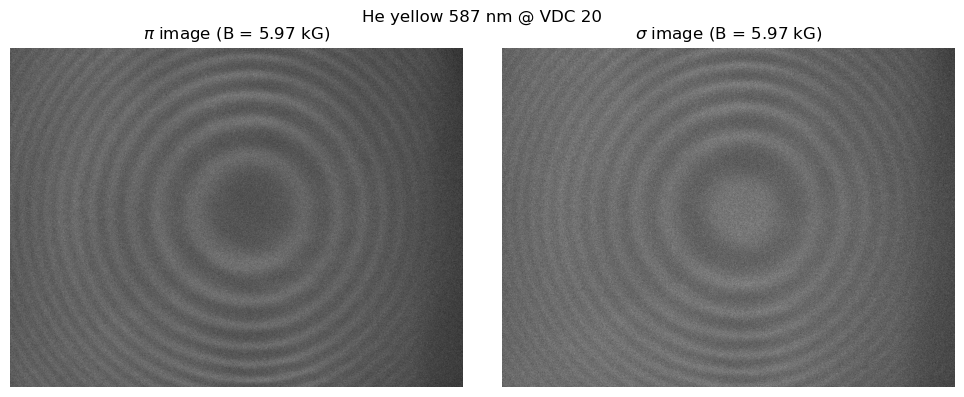

In [3]:
# Preview example images (VDC = 20)

import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

vdc_example = 20
idx = VDC_VALUES.index(vdc_example)
B_kG = float(B_FIELDS_KG[idx])

sigma_path = data_dir / f"vdc{vdc_example}_He_yellow_587_sigma.png"
pi_path = data_dir / f"vdc{vdc_example}_He_yellow_587_pi.png"

sigma_img = np.array(Image.open(sigma_path).convert("L"))
pi_img = np.array(Image.open(pi_path).convert("L"))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(pi_img, cmap="gray")
axes[0].set_title(f"$\\pi$ image (B = {B_kG:.2f} kG)")
axes[0].axis("off")

axes[1].imshow(sigma_img, cmap="gray")
axes[1].set_title(f"$\\sigma$ image (B = {B_kG:.2f} kG)")
axes[1].axis("off")

fig.suptitle(f"He yellow 587 nm @ VDC {vdc_example}")
fig.tight_layout()

In [4]:
from zeeman_analysis_pipeline import load_or_compute_profiles

# If cache exists, this loads immediately. Otherwise it preprocesses and saves.
I_r_arr, r_arr, centers = load_or_compute_profiles(
    image_paths=[str(p) for p in image_paths],
    cache_dir=cache_dir,
    force_recompute=False,
    nbins=nbins,
    verbose=True,
    center_step=center_step,
)

print('Cached profiles:', len(r_arr))
print('Centers shape:', centers.shape)
centers[:3]

Cached profiles: 14
Centers shape: (14, 2)


array([[758., 516.],
       [758., 518.],
       [756., 516.]])

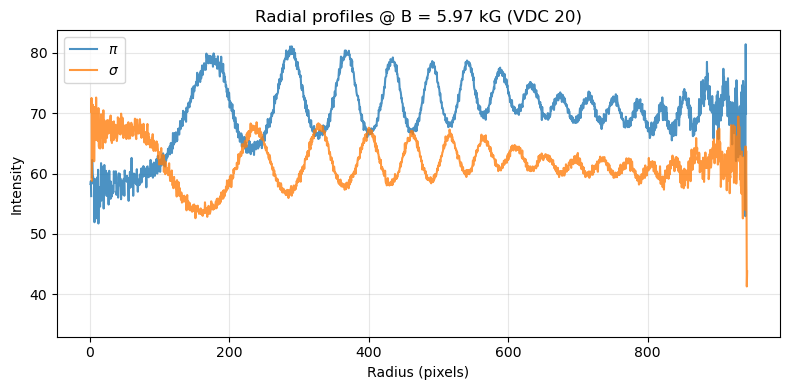

In [5]:
# Plot radial profiles (σ and π) overlaid for VDC 20
# Run the preprocessing cell above first.

vdc_example = 20
idx = VDC_VALUES.index(vdc_example)
B_kG = float(B_FIELDS_KG[idx])
sigma_idx = 2 * idx
pi_idx = 2 * idx + 1

r_sigma = np.asarray(r_arr[sigma_idx], dtype=float)
I_sigma = np.asarray(I_r_arr[sigma_idx], dtype=float)
r_pi = np.asarray(r_arr[pi_idx], dtype=float)
I_pi = np.asarray(I_r_arr[pi_idx], dtype=float)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r_pi, I_pi, label=r"$\pi$", alpha=0.8)
ax.plot(r_sigma, I_sigma, label=r"$\sigma$", alpha=0.8)
ax.set_xlabel("Radius (pixels)")
ax.set_ylabel("Intensity")
ax.set_title(f"Radial profiles @ B = {B_kG:.2f} kG (VDC {vdc_example})")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

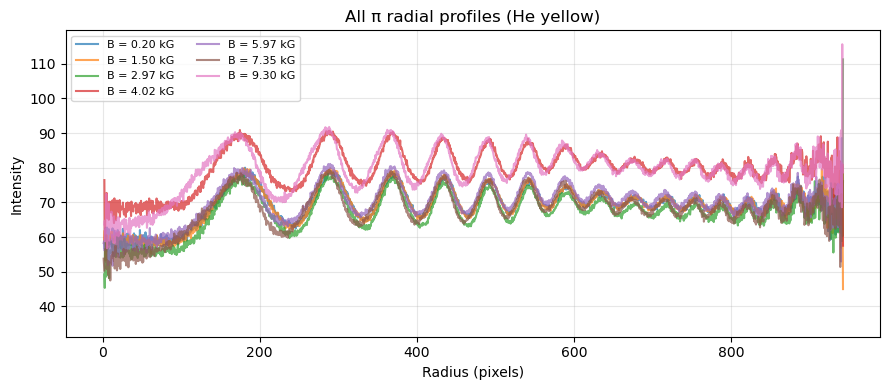

In [6]:
# Overlay ALL π radial profiles (one per VDC)
fig, ax = plt.subplots(figsize=(9, 4))
for idx in range(len(VDC_VALUES)):
    pi_idx = 2 * idx + 1
    r_pi = np.asarray(r_arr[pi_idx], dtype=float)
    I_pi = np.asarray(I_r_arr[pi_idx], dtype=float)
    B_kG = float(B_FIELDS_KG[idx])
    ax.plot(r_pi, I_pi, alpha=0.7, label=f"B = {B_kG:.2f} kG")
ax.set_xlabel("Radius (pixels)")
ax.set_ylabel("Intensity")
ax.set_title("All π radial profiles (He yellow)")
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

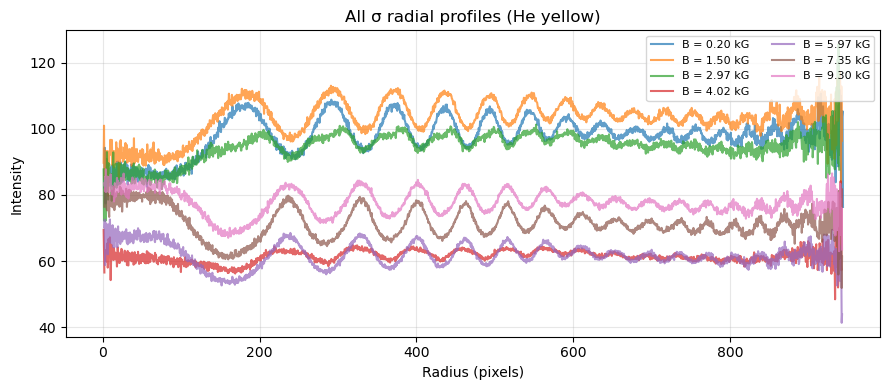

In [7]:
# Overlay ALL σ radial profiles (one per VDC)
fig, ax = plt.subplots(figsize=(9, 4))
for idx in range(len(VDC_VALUES)):
    sigma_idx = 2 * idx
    r_sigma = np.asarray(r_arr[sigma_idx], dtype=float)
    I_sigma = np.asarray(I_r_arr[sigma_idx], dtype=float)
    B_kG = float(B_FIELDS_KG[idx])
    ax.plot(r_sigma, I_sigma, alpha=0.7, label=f"B = {B_kG:.2f} kG")
ax.set_xlabel("Radius (pixels)")
ax.set_ylabel("Intensity")
ax.set_title("All σ radial profiles (He yellow)")
ax.legend(ncol=2, fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [3]:
from zeeman_yellow import run_yellow_analysis, plot_results

# g_effective: for anomalous Zeeman you may want a theoretical/expected g for the chosen component.
g_effective = 1.0

df_ring, df_summary, magneton = run_yellow_analysis(
    cache_dir=cache_dir,
    B_fields_kG=B_FIELDS_KG,
    etalon_thickness_cm=etalon_thickness_cm,
    g_effective=g_effective,
)

out_ring = cache_dir / 'zeeman_yellow_ringwise.csv'
out_sum = cache_dir / 'zeeman_yellow_summary.csv'
out_png = cache_dir / 'zeeman_yellow_vs_B.png'

df_ring.to_csv(out_ring, index=False)
df_summary.to_csv(out_sum, index=False)
plot_results(df_summary, magneton, out_png)

print('Saved:', out_ring)
print('Saved:', out_sum)
print('Saved:', out_png)
magneton

Saved plot to C:\Users\Aditi\Physics111B\ATM\zeeman\yellow_cache\zeeman_yellow_vs_B.png
Saved: C:\Users\Aditi\Physics111B\ATM\zeeman\yellow_cache\zeeman_yellow_ringwise.csv
Saved: C:\Users\Aditi\Physics111B\ATM\zeeman\yellow_cache\zeeman_yellow_summary.csv
Saved: C:\Users\Aditi\Physics111B\ATM\zeeman\yellow_cache\zeeman_yellow_vs_B.png


{'slope_cm_inv_per_G': 4.322829530139106e-06,
 'slope_unc': 8.632176760919418e-06,
 'intercept_cm_inv': 0.06159002623407883,
 'mu_B_J_per_T': 8.587066811305878e-25,
 'mu_B_unc_J_per_T': 1.714735176490564e-24,
 'g_effective': 1.0,
 'accepted_mu_B': 9.2740100783e-24}